<a href="https://colab.research.google.com/github/Alister44/Melbourne_Housing/blob/main/notebooks/solution_easy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

In [70]:
FILE_IN = 'https://raw.githubusercontent.com/Alister44/Melbourne_Housing/refs/heads/main/data/melb_data_dirty.csv'
df_original = pd.read_csv(FILE_IN)
df = df_original.copy()

In [71]:
display(df.head())

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


Suburb	-  Район  
Address	- Адрес  
Rooms - Количество комнат  
Type - Тип  
br — спальни;   
h — дом, коттедж, вилла, дом с общей стеной (semi-detached), таунхаус рядовой застройки (terrace);   
u — квартира, дуплекс;   
t — таунхаус;  
dev site — участок под застройку;   
o res — прочая жилая недвижимость.  
Price - Цена  
Method - Способ продажи  
`S` — объект продан; `SP` — продан до аукциона; `PI` — торги не состоялись (объект не продан); `PN` — продан до аукциона (цена не разглашается); `SN` — продан (цена не разглашается); `NB` — ставок не было; `VB` — ставка продавца; `W` — снят с продажи до аукциона; `SA` — продан после аукциона; `SS` — продан после аукциона (цена не разглашается). `N/A` — цена или максимальная ставка неизвестны.
SellerG-Агентство  
Date - Дата(продажи)  
Distance - Расстояние  
Postcode - Почтовый индекс  
Bedroom2 - Спальни  
Bathroom - Ванные комнаты  
Car	Парковочные места  
Landsize	Площадь участка  
BuildingArea	Площадь строения  
YearBuilt	Год постройки  
CouncilArea	Муниципальный округ  
Lattitude	Широта  
Longtitude	Долгота  
Regionname	Регион  
Propertycount	Количество объектов недвижимости в данном районе  


# описова статистика числових стовпців

In [72]:
display(df.describe().round(3))


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000,13580.000,13580.000,13580.000,13580.000,13580.000,13518.000,13580.000,7130.000,8205.000,13580.000,13580.000,13580.000
mean,2.938,1075684.079,10.138,3105.302,2.915,1.534,1.610,558.416,151.968,1964.684,-37.809,144.995,7454.417
std,0.956,639310.724,5.869,90.677,0.966,0.692,0.963,3990.669,541.015,37.274,0.079,0.104,4378.582
min,1.000,85000.000,0.000,3000.000,0.000,0.000,0.000,0.000,0.000,1196.000,-38.183,144.432,249.000
25%,2.000,650000.000,6.100,3044.000,2.000,1.000,1.000,177.000,93.000,1940.000,-37.857,144.930,4380.000
50%,3.000,903000.000,9.200,3084.000,3.000,1.000,2.000,440.000,126.000,1970.000,-37.802,145.000,6555.000
75%,3.000,1330000.000,13.000,3148.000,3.000,2.000,2.000,651.000,174.000,1999.000,-37.756,145.058,10331.000
max,10.000,9000000.000,48.100,3977.000,20.000,8.000,10.000,433014.000,44515.000,2018.000,-37.409,145.526,21650.000


описова статистика всіх стопвпців

In [73]:
display(df.describe(include='all'))

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
count,13580,13580,13580.000000,13580,1.358000e+04,13580,13580,13580,13580.000000,13580.000000,...,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,12211,13580.000000,13580.000000,13580,13580.000000
unique,314,13378,NaN,3,NaN,5,268,58,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,33,NaN,NaN,8,NaN
top,Reservoir,5 Margaret St,NaN,h,NaN,S,Nelson,27/05/2017,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Moreland,NaN,NaN,Southern Metropolitan,NaN
freq,359,3,NaN,9449,NaN,9022,1565,473,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1163,NaN,NaN,4695,NaN
mean,NaN,NaN,2.937997,NaN,1.075684e+06,NaN,NaN,NaN,10.137776,3105.301915,...,1.534242,1.610075,558.416127,151.967650,1964.684217,NaN,-37.809203,144.995216,NaN,7454.417378
std,NaN,NaN,0.955748,NaN,6.393107e+05,NaN,NaN,NaN,5.868725,90.676964,...,0.691712,0.962634,3990.669241,541.014538,37.273762,NaN,0.079260,0.103916,NaN,4378.581772
min,NaN,NaN,1.000000,NaN,8.500000e+04,NaN,NaN,NaN,0.000000,3000.000000,...,0.000000,0.000000,0.000000,0.000000,1196.000000,NaN,-38.182550,144.431810,NaN,249.000000
25%,NaN,NaN,2.000000,NaN,6.500000e+05,NaN,NaN,NaN,6.100000,3044.000000,...,1.000000,1.000000,177.000000,93.000000,1940.000000,NaN,-37.856822,144.929600,NaN,4380.000000
50%,NaN,NaN,3.000000,NaN,9.030000e+05,NaN,NaN,NaN,9.200000,3084.000000,...,1.000000,2.000000,440.000000,126.000000,1970.000000,NaN,-37.802355,145.000100,NaN,6555.000000
75%,NaN,NaN,3.000000,NaN,1.330000e+06,NaN,NaN,NaN,13.000000,3148.000000,...,2.000000,2.000000,651.000000,174.000000,1999.000000,NaN,-37.756400,145.058305,NaN,10331.000000


Анализ пропущенных значений и типов


In [74]:
def info():
    return pd.DataFrame({
    "тип": df.dtypes.astype(str),
    'кількість пропусків': df.isnull().sum(),
    "пропусків_%": (df.isna().mean() * 100).round(1),
    }).sort_values("пропусків_%", ascending=False)

info()



,тип,кількість пропусків,пропусків_%
BuildingArea,float64,6450,47.5
YearBuilt,float64,5375,39.6
CouncilArea,object,1369,10.1
Car,float64,62,0.5
Suburb,object,0,0.0
Price,float64,0,0.0
Type,object,0,0.0
Rooms,int64,0,0.0
Address,object,0,0.0
Distance,float64,0,0.0


Перевірка чи немає технічного стовпця-індексу, який потрапив у файл.Якщо є - прибераєм

In [75]:
clean = df.copy()
if 'Unnamed: 0' in clean.columns:
  clean = clean.drop(columns=['Unnamed: 0'])
  print('Column with index - deleted')

Перетворюю типи стовпців на корректні

In [76]:
df['Date'] = pd.to_datetime(df['Date'],errors='coerce', dayfirst=True)
df['YearBuilt'] = df['YearBuilt'].astype('Int32')
df['Rooms'] = df['Rooms'].astype('Int8')
df['Bedroom2'] = df['Bedroom2'].astype('Int8')
df['Bathroom'] = df['Bathroom'].astype('Int8')
df['Car'] = df['Car'].astype('Int8')
df['Propertycount'] = df['Propertycount'].astype('Int64')
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-12-03,2.5,3067.0,...,1,1,202.0,NaN,<NA>,Yarra,-37.7996,144.9984,Northern Metropolitan,4019
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-02-04,2.5,3067.0,...,1,0,156.0,79.0,1900,Yarra,-37.8079,144.9934,Northern Metropolitan,4019
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-03-04,2.5,3067.0,...,2,0,134.0,150.0,1900,Yarra,-37.8093,144.9944,Northern Metropolitan,4019
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2017-03-04,2.5,3067.0,...,2,1,94.0,NaN,<NA>,Yarra,-37.7969,144.9969,Northern Metropolitan,4019
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2016-06-04,2.5,3067.0,...,1,2,120.0,142.0,2014,Yarra,-37.8072,144.9941,Northern Metropolitan,4019


Перевіряю, чи корректно помінялись типи

In [77]:
info_col = pd.DataFrame({
    "тип": df.dtypes.astype(str)
})
info_col

,тип
Suburb,object
Address,object
Rooms,Int8
Type,object
Price,float64
Method,object
SellerG,object
Date,datetime64[ns]
Distance,float64
Postcode,float64


Замінюємо нулі, що насправді означають "немає даних". Наприклад, немає квартир з нульовою площою

In [78]:
for col in ['Landsize','BuildingArea']:
    df.loc[df[col] == 0, col] = np.nan

In [79]:
df['BuildingArea'] = df['BuildingArea'].replace(0,pd.NA) # замінюємо квартири з площею 0 на NA
df['BuildingArea'].head()

,BuildingArea
0,NaN
1,79.0
2,150.0
3,NaN
4,142.0


Перевіряємо чи коректно вказана дата постройки, виводимо у зростаючому порядку декілька рядків. Бачимо що 1196 - явно помилка.Далі йде 1830, це більше схоже на правду

In [80]:
df['YearBuilt'].sort_values().head()

,YearBuilt
9968,1196
2079,1830
4843,1850
5405,1850
2554,1850


In [81]:
df.loc[df['YearBuilt'] == 1196, 'YearBuilt'] = pd.NA # поменяли "1196" на NA
df['YearBuilt'].sort_values(ascending=False).head()# проверили нет ли ошибочной максимальной даты


,YearBuilt
1234,2018
12428,2017
10733,2017
13437,2017
12629,2017


Проверяем на дубликаты

In [82]:
print(f"Дублікатів: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Дублікатів після видалення: {df.duplicated().sum()}")

Дублікатів: 0
Дублікатів після видалення: 0


In [83]:
info()

,тип,кількість пропусків,пропусків_%
BuildingArea,float64,6467,47.6
YearBuilt,Int32,5376,39.6
Landsize,float64,1939,14.3
CouncilArea,object,1369,10.1
Car,Int8,62,0.5
Price,float64,0,0.0
Type,object,0,0.0
Rooms,Int8,0,0.0
Address,object,0,0.0
Suburb,object,0,0.0


стратегія щодо пропусків - для стовпців з дуже високою часткою пропусків подумайте, чи варто їх взагалі використовувати; для решти сплануйте заповнення (числові - якоюсь типовою величиною, категорійні - найчастішим значенням). Важливо: заповнення варто робити так, щоб інформація з тестової вибірки не "просочувалася" у навчання.

# Дата

In [84]:
df.loc[df['Date'].isna(),'Method'].unique()

array([], dtype=object)

Бачимо, що дата продажу відсутня тільки у домах з наступними методами продажу 'S', 'SP', 'PI', 'VB', 'SA'. Можливо дата продажу відсутня бо продаж ще не состоявся. PI — не продано, VB — это ставка самого продавца, дом фактически не продан, значит это нормально что дата не заполнена здесь. а S — продано,
SP — продано до аукциона, SA — продано после аукциона здесь уже отсутствие даты это не нормально (при сборе данных забыли записать)

Прежде чем удалять рядки с 'S', 'SP', 'SA' посмотрим сколько данных относительно всего датасета можем потерять.

In [85]:
print(f'Если удалим рядки без даты продажи, то потеряем {round(df[df['Method'].isin(['S', 'SP', 'SA']) & df['Date'].isna()].shape[0] / len(df) * 100,2)} % данных')


Если удалим рядки без даты продажи, то потеряем 0.0 % данных


Исходя из полученных результатов делаем вывод что удалять эти рядки неразумно. Оставляем их как NA

In [86]:
info()

,тип,кількість пропусків,пропусків_%
BuildingArea,float64,6467,47.6
YearBuilt,Int32,5376,39.6
Landsize,float64,1939,14.3
CouncilArea,object,1369,10.1
Car,Int8,62,0.5
Price,float64,0,0.0
Type,object,0,0.0
Rooms,Int8,0,0.0
Address,object,0,0.0
Suburb,object,0,0.0


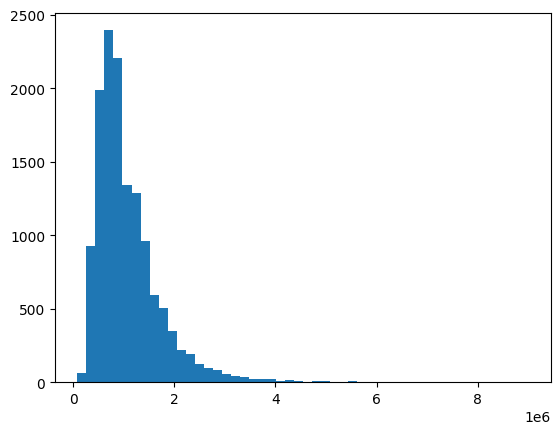

In [87]:
plt.hist(df["Price"], bins=50)
plt.show()

Тут видим что цены скошены в правую сторону. То есть большинство квартир сосредоточены на отрезке (до 1млн) и длинный хвост цен дорогих квартир от 1 до 9 млн. Поскольку большинство моделей думает что распределение предполагается нормальнім и равномерным, то им трудно будет предугадать цену  дорогой квартиры. Если будем использовать линейную регрессию в качестве модели прогнозирования, желательно создать новый столбец с логарифмом от цены, чтобы модель обучалась по нему.

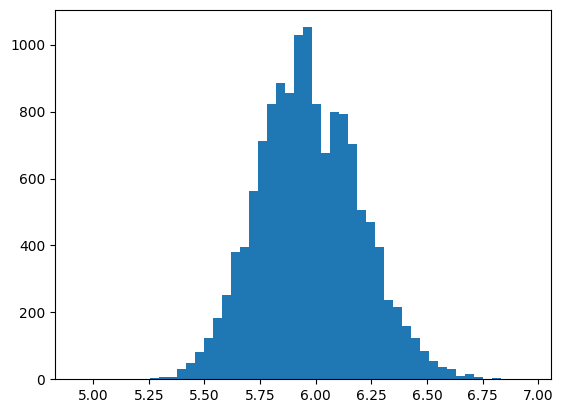

In [88]:
# преобразовали цену к логарифму и получили нормальное распределение
plt.hist(np.log10(df["Price"]), bins=50)
plt.show()

як ціна залежить від типу житла та району?

<Axes: title={'center': 'Price'}, xlabel='Type'>

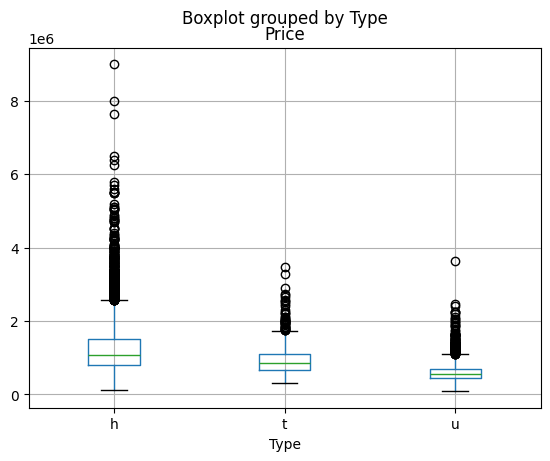

In [89]:
df.boxplot(column="Price", by="Type")

h - отдельный дом или его разновидности (коттедж, вилла, таунхаус-терраса)  
u - unit, duplex квартира в многоквартирном доме или дуплекс (дом на двух хозяев)  
t - townhouse таунхаус — многоэтажный дом вплотную к соседним, отдельный вход

У домов имеем самый большой разброс по экстремально высоким ценам(выбросы от 2.8млн до 9 млн.)  
У тансхаусов также имеем большое количество экстремально высоких цен (но разброс не такой длинный как у домов( примерно от 1.8 до 2.8 млн.))  
У квартир видим, что в основном цены располагаются в диапазоне 350к–700к. однако также есть экстремально высоки цены за квартиры в диапазоне от 1.1 почти до 4 млн.

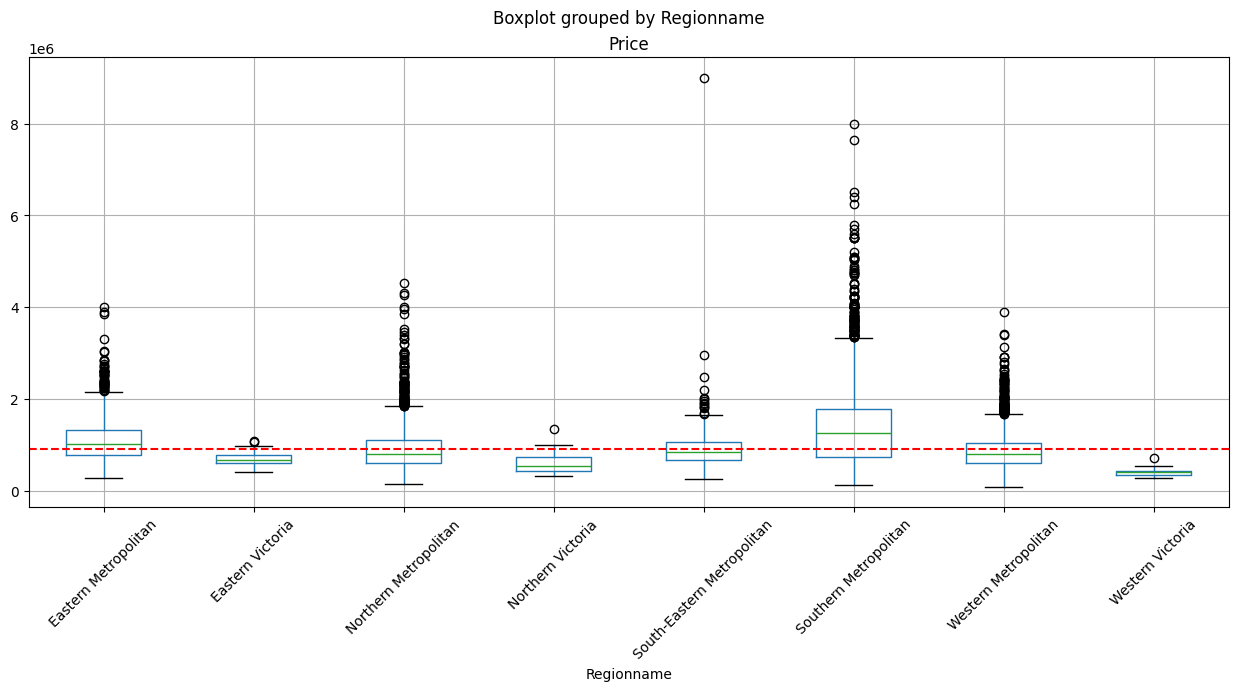

In [90]:
ax = df.boxplot(column="Price", by="Regionname", figsize=(15, 6), rot=45,grid=True)
ax.axhline(df['Price'].median(), color='red', linestyle='--')
plt.show()

зв'язок числових ознак із ціною (кореляції)

In [91]:
# 4) кореляція числових ознак ІЗ ЦІНОЮ:
#    - візьміть лише числові стовпці: num = clean.select_dtypes("number")
#    - порахуйте num.corr()
#    - візьміть стовпець ["Price"], приберіть сам Price (.drop("Price"))
#    - відсортуйте за модулем: .sort_values(key=abs, ascending=False)
#    - надрукуйте і прочитайте: що найсильніше пов'язане з ціною?
# ...
num = df.select_dtypes("number")
num.corr()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
Rooms,1.000000,0.496634,0.294203,0.055303,0.944190,0.592934,0.408483,0.002409,0.124682,-0.067006,0.015948,0.100771,-0.081530
Price,0.496634,1.000000,-0.162522,0.107867,0.475951,0.467038,0.238979,0.023258,0.091576,-0.331828,-0.212934,0.203656,-0.042153
Distance,0.294203,-0.162522,1.000000,0.431514,0.295927,0.127155,0.262994,0.010781,0.099802,0.254860,-0.130723,0.239425,-0.054910
Postcode,0.055303,0.107867,0.431514,1.000000,0.060584,0.113664,0.050289,0.026365,0.055604,0.035004,-0.406104,0.445357,0.062304
Bedroom2,0.944190,0.475951,0.295927,0.060584,1.000000,0.584685,0.405325,0.003241,0.122895,-0.054523,0.015925,0.102238,-0.081350
Bathroom,0.592934,0.467038,0.127155,0.113664,0.584685,1.000000,0.322246,0.028629,0.112263,0.154722,-0.070594,0.118971,-0.052201
Car,0.408483,0.238979,0.262994,0.050289,0.405325,0.322246,1.000000,0.015711,0.096332,0.114110,-0.001963,0.063395,-0.024295
Landsize,0.002409,0.023258,0.010781,0.026365,0.003241,0.028629,0.015711,1.000000,0.501393,0.079759,0.005241,0.009340,-0.002872
BuildingArea,0.124682,0.091576,0.099802,0.055604,0.122895,0.112263,0.096332,0.501393,1.000000,0.020685,0.043701,-0.023537,-0.028776
YearBuilt,-0.067006,-0.331828,0.254860,0.035004,-0.054523,0.154722,0.114110,0.079759,0.020685,1.000000,0.060163,-0.000353,0.010033


In [92]:
num.corr()["Price"]

,Price
Rooms,0.496634
Price,1.000000
Distance,-0.162522
Postcode,0.107867
Bedroom2,0.475951
Bathroom,0.467038
Car,0.238979
Landsize,0.023258
BuildingArea,0.091576
YearBuilt,-0.331828


In [93]:
num.corr()["Price"].drop("Price").sort_values(key=abs, ascending=False)


,Price
Rooms,0.496634
Bedroom2,0.475951
Bathroom,0.467038
YearBuilt,-0.331828
Car,0.238979
Lattitude,-0.212934
Longtitude,0.203656
Distance,-0.162522
Postcode,0.107867
BuildingArea,0.091576


Видим что наисильнее связвны с ценой: количество комнат, спален, и ванных комнат. Интересно, что размер участка так слабо связан с ценой, ведь цена частных домов с участком обычно выше чем квартир.Исамое главное: больше участок -> больше цена. Возможно если бы мы рассчитали корелляцию отдельно для квартир и домов, то для домов Landsize дал бы большую корелляцию. а для квартир такую же маленькую, поскольку у квартир отсутствует придомовая территория(сад, двор)

In [98]:
df_drop = df.copy()
df_drop = df_drop.dropna()
print("before drop:", df.shape)
print("ater drop:", df_drop.shape)
num = df_drop.select_dtypes("number")
num.corr()['Price'].drop("Price").sort_values(key=abs, ascending=False).round(3)

before drop: (13580, 21)
ater drop: (5179, 21)


,Price
BuildingArea,0.492
Bathroom,0.469
Rooms,0.466
Bedroom2,0.443
YearBuilt,-0.297
Lattitude,-0.260
Distance,-0.255
Longtitude,0.217
Car,0.203
Postcode,0.137


# Крок 5. Нові ознаки (feature engineering)

In [103]:
fe = df.copy()

# 1) частини дати продажу
#    - рік: fe["sale_year"] = fe["Date"].dt.year
#    - місяць: за аналогією дістаньте .dt.month
# ...
fe["sale_year"] = fe["Date"].dt.year
fe["sale_month"] = fe["Date"].dt.month

# 2) вік будинку на момент продажу
#    - це рік продажу мінус рік побудови (YearBuilt)
#    - підстрахуйтесь: якщо вийшло від'ємне число, замініть на np.nan
# ...
fe["age"] = fe["sale_year"] -  fe["YearBuilt"]
fe.loc[fe['age']<0,'age'] = np.nan

# 3) прапорці наявності (пропуск як сигнал)
#    - для BuildingArea: fe["has_buildingarea"] = fe["BuildingArea"].notna().astype(int)
#    - зробіть так само has_yearbuilt для YearBuilt
# ...
fe["has_buildingarea"] = fe["BuildingArea"].notna().astype(int)
fe["has_yearbuilt"] = fe["YearBuilt"].notna().astype(int)

# 4) частотне кодування району Suburb
#    - підказка: fe["suburb_freq"] = fe["Suburb"].map(fe["Suburb"].value_counts())
# ...
fe["suburb_freq"] = fe["Suburb"].map(fe["Suburb"].value_counts())
# 5) приберіть зайве:
#    - дубль ознаки (наприклад, Bedroom2, бо схожий на Rooms)
#    - надто розріджені стовпці й текст, який не кодуєте (Address, SellerG, Suburb тощо)
#    - використайте fe.drop(columns=[...])
# ...
drop_cols = ['Bedroom2', 'Address', 'SellerG', 'Suburb', ]

In [102]:
fe["Suburb"].describe()

,Suburb
count,13580
unique,314
top,Reservoir
freq,359
